# Exploratory Data Analysis: Bivariate

## 1. Import packages

In [55]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 2. Load data

Load the merged data set `noaa_cdc_uscensus.csv` and get familiar with it.

In [2]:

df = pd.read_csv("../data/noaa_cdc_uscensus.csv")
df.head()

,year,stateabbr_c,statedesc_c,locationname_c,category_c,locationid_c,measure_c,data_value_c,low_confidence_limit_c,high_confidence_limit_c,...,pct_female_u,cbsa_code_u,median_household_income_u,pct_bachelors_plus_u,pct_graduate_degree_u,pct_less_than_hs_u,pct_white_u,pct_black_u,pct_hispanic_u,pct_asian_u
0,2014,AL,Alabama,Mobile,Health Outcomes,150000,Chronic obstructive pulmonary disease among ad...,8.7,8.5,8.8,...,52.1,33660.0,43844.0,6.7,13.2,4.5,58.4,34.9,2.6,1.9
1,2014,AL,Alabama,Tuscaloosa,Health Outcomes,177256,Chronic obstructive pulmonary disease among ad...,9.1,8.9,9.4,...,51.8,46220.0,43567.0,5.6,14.1,4.5,61.6,33.2,2.8,1.2
2,2014,AL,Alabama,Birmingham,Health Outcomes,107000,Chronic obstructive pulmonary disease among ad...,9.4,9.3,9.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,AL,Alabama,Montgomery,Health Outcomes,151000,Chronic obstructive pulmonary disease among ad...,8.6,8.5,8.8,...,52.0,33860.0,46977.0,6.2,16.0,5.2,50.5,43.0,3.1,1.7
4,2014,AL,Alabama,Huntsville,Health Outcomes,137000,Chronic obstructive pulmonary disease among ad...,7.5,7.4,7.7,...,50.7,26620.0,55881.0,6.9,22.7,3.8,68.2,21.5,4.9,2.2


## 3. Wrangle and inspect data

### 3.1. Pivot to wider format

In [3]:
measure_specific = ['measureid_c', 'measure_c', 'data_value_c', 'low_confidence_limit_c',
                    'high_confidence_limit_c', 'category_c', 'categoryid_c', 'short_question_text_c']
index_cols = [c for c in df.columns if c not in measure_specific]

df_pivot = df.pivot(
    index=index_cols,
    columns='measureid_c',
    values=['data_value_c', 'low_confidence_limit_c', 'high_confidence_limit_c']
).reset_index()

df_pivot.columns = [''.join(col).strip('') if isinstance(col, tuple) else col for col in df_pivot.columns]

print(df_pivot.shape)
df_pivot.head()

(1818, 70)


,year,stateabbr_c,statedesc_c,locationname_c,locationid_c,totalpopulation_c,geolocation_c,sca_release_id_c,msa_c,msa_code,...,low_confidence_limit_cPHLTH,low_confidence_limit_cSTROKE,high_confidence_limit_cCASTHMA,high_confidence_limit_cCHD,high_confidence_limit_cCOPD,high_confidence_limit_cLPA,high_confidence_limit_cMHLTH,high_confidence_limit_cOBESITY,high_confidence_limit_cPHLTH,high_confidence_limit_cSTROKE
0,2014,AK,Alaska,Anchorage,203000,"291,826","(61.149868731, -149.111113424)",2014_500_Cities_2016_release,"Anchorage, AK Metro Area",112.0,...,9.8,2.6,8.6,5.1,5.1,19.5,9.5,27.9,10.1,2.6
1,2014,AL,Alabama,Birmingham,107000,"212,237","(33.5275663773, -86.7988174678)",2014_500_Cities_2016_release,"Birmingham, AL Metro Area",136.0,...,18.0,5.0,11.5,7.7,9.6,32.1,17.2,39.1,18.5,5.1
2,2014,AL,Alabama,Huntsville,137000,"180,105","(34.6989692671, -86.6387042882)",2014_500_Cities_2016_release,"Huntsville, AL Metro Area",259.0,...,13.7,3.1,9.7,6.8,7.7,25.3,14.2,32.2,14.2,3.2
3,2014,AL,Alabama,Mobile,150000,"195,111","(30.6776248648, -88.1184482714)",2014_500_Cities_2016_release,"Mobile, AL Metro Area",333.0,...,16.1,4.0,10.8,7.7,8.8,27.8,16.0,37.8,16.5,4.1
4,2014,AL,Alabama,Montgomery,151000,"205,764","(32.3472645333, -86.2677059552)",2014_500_Cities_2016_release,"Montgomery, AL Metro Area",337.0,...,16.0,4.0,10.9,7.3,8.8,28.3,15.7,37.1,16.4,4.1


### 3.2. Inspect pivoted data set

In [16]:
df_pivot.info()

<class 'pandas.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   year                            1818 non-null   int64  
 1   stateabbr_c                     1818 non-null   str    
 2   statedesc_c                     1818 non-null   str    
 3   locationname_c                  1818 non-null   str    
 4   locationid_c                    1818 non-null   int64  
 5   totalpopulation_c               1818 non-null   str    
 6   geolocation_c                   1818 non-null   str    
 7   sca_release_id_c                1818 non-null   str    
 8   msa_c                           1818 non-null   str    
 9   msa_code                        1818 non-null   float64
 10  state_c                         1818 non-null   str    
 11  short_name_c                    1818 non-null   str    
 12  source_dataset_c                1818 non-null

In [17]:
df_pivot.describe()

,year,locationid_c,msa_code,year_coverage_c,latitude_n,longitude_n,cldd_n,dt00_n,dt32_n,dx32_n,...,low_confidence_limit_cPHLTH,low_confidence_limit_cSTROKE,high_confidence_limit_cCASTHMA,high_confidence_limit_cCHD,high_confidence_limit_cCOPD,high_confidence_limit_cLPA,high_confidence_limit_cMHLTH,high_confidence_limit_cOBESITY,high_confidence_limit_cPHLTH,high_confidence_limit_cSTROKE
count,1818.000000,1.818000e+03,1818.000000,1818.000000,1791.000000,1791.000000,1681.000000,1691.000000,1691.000000,1692.000000,...,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000
mean,2018.435094,2.828697e+06,299.314631,9.841584,37.219230,-95.088028,1006.305651,2.570668,72.897694,14.960993,...,12.772772,3.311276,10.662541,6.399780,7.223982,28.276733,16.155941,36.014356,13.931408,3.548130
std,2.875211,1.711860e+06,114.431307,0.727771,5.415014,15.845681,660.722449,5.599044,54.278132,20.079903,...,2.211980,0.678719,1.552720,0.879479,1.541453,6.010758,3.264055,6.848094,2.352218,0.707736
min,2014.000000,1.500300e+04,100.000000,4.000000,21.324020,-157.939460,0.000000,0.000000,0.000000,0.000000,...,7.000000,2.000000,7.500000,4.000000,3.500000,11.200000,8.600000,16.100000,7.400000,2.200000
25%,2016.000000,1.235000e+06,193.000000,10.000000,32.838390,-105.085750,472.400000,0.000000,19.000000,0.000000,...,11.300000,2.800000,9.500000,5.900000,6.200000,24.000000,13.700000,31.400000,12.400000,3.100000
50%,2018.000000,2.792290e+06,309.000000,10.000000,37.511540,-91.544550,810.200000,0.000000,73.000000,4.000000,...,12.800000,3.200000,10.500000,6.400000,7.100000,28.350000,15.700000,35.900000,13.900000,3.500000
75%,2021.000000,4.513330e+06,397.000000,10.000000,41.194060,-82.276030,1460.900000,3.000000,120.000000,26.000000,...,14.100000,3.700000,11.700000,6.900000,8.000000,32.175000,18.700000,40.475000,15.400000,3.900000
max,2023.000000,5.613900e+06,486.000000,10.000000,61.156100,-70.304430,3123.900000,48.000000,197.000000,127.000000,...,20.900000,6.300000,16.400000,9.700000,13.300000,47.400000,26.400000,56.800000,21.600000,6.400000


In [77]:
df_pivot.head()

,year,stateabbr_c,statedesc_c,locationname_c,locationid_c,totalpopulation_c,geolocation_c,sca_release_id_c,msa_c,msa_code,...,low_confidence_limit_cPHLTH,low_confidence_limit_cSTROKE,high_confidence_limit_cCASTHMA,high_confidence_limit_cCHD,high_confidence_limit_cCOPD,high_confidence_limit_cLPA,high_confidence_limit_cMHLTH,high_confidence_limit_cOBESITY,high_confidence_limit_cPHLTH,high_confidence_limit_cSTROKE
0,2014,AK,Alaska,Anchorage,203000,"291,826","(61.149868731, -149.111113424)",2014_500_Cities_2016_release,"Anchorage, AK Metro Area",112.0,...,9.8,2.6,8.6,5.1,5.1,19.5,9.5,27.9,10.1,2.6
1,2014,AL,Alabama,Birmingham,107000,"212,237","(33.5275663773, -86.7988174678)",2014_500_Cities_2016_release,"Birmingham, AL Metro Area",136.0,...,18.0,5.0,11.5,7.7,9.6,32.1,17.2,39.1,18.5,5.1
2,2014,AL,Alabama,Huntsville,137000,"180,105","(34.6989692671, -86.6387042882)",2014_500_Cities_2016_release,"Huntsville, AL Metro Area",259.0,...,13.7,3.1,9.7,6.8,7.7,25.3,14.2,32.2,14.2,3.2
3,2014,AL,Alabama,Mobile,150000,"195,111","(30.6776248648, -88.1184482714)",2014_500_Cities_2016_release,"Mobile, AL Metro Area",333.0,...,16.1,4.0,10.8,7.7,8.8,27.8,16.0,37.8,16.5,4.1
4,2014,AL,Alabama,Montgomery,151000,"205,764","(32.3472645333, -86.2677059552)",2014_500_Cities_2016_release,"Montgomery, AL Metro Area",337.0,...,16.0,4.0,10.9,7.3,8.8,28.3,15.7,37.1,16.4,4.1


In [19]:
df_pivot.isnull().sum()

year                              0
stateabbr_c                       0
statedesc_c                       0
locationname_c                    0
locationid_c                      0
                                 ..
high_confidence_limit_cLPA        0
high_confidence_limit_cMHLTH      0
high_confidence_limit_cOBESITY    0
high_confidence_limit_cPHLTH      0
high_confidence_limit_cSTROKE     0
Length: 70, dtype: int64

### 3.3. Drop unnecessary columns

In [82]:
df_pivot.columns

Index(['year', 'stateabbr_c', 'statedesc_c', 'locationname_c', 'locationid_c', 'totalpopulation_c', 'geolocation_c',
       'sca_release_id_c', 'msa_c', 'msa_code', 'state_c', 'short_name_c', 'source_dataset_c', 'year_coverage_c',
       'latitude_n', 'longitude_n', 'name_n', 'cldd_n', 'dt00_n', 'dt32_n', 'dx32_n', 'dx70_n', 'dx90_n', 'emnt_n',
       'emxt_n', 'htdd_n', 'prcp_n', 'tavg_n', 'tmax_n', 'tmin_n', 'tsun_n', 'msa_n', 'msa_u', 'total_population_u',
       'median_age_u', 'pct_male_u', 'pct_female_u', 'cbsa_code_u', 'median_household_income_u', 'pct_bachelors_plus_u',
       'pct_graduate_degree_u', 'pct_less_than_hs_u', 'pct_white_u', 'pct_black_u', 'pct_hispanic_u', 'pct_asian_u',
       'data_value_cCASTHMA', 'data_value_cCHD', 'data_value_cCOPD', 'data_value_cLPA', 'data_value_cMHLTH',
       'data_value_cOBESITY', 'data_value_cPHLTH', 'data_value_cSTROKE', 'low_confidence_limit_cCASTHMA',
       'low_confidence_limit_cCHD', 'low_confidence_limit_cCOPD', 'low_confidence_l

## 4. Visualize bivariate relationships I: Health vs. weather

### 4.1. Compute a correlation matrix and plot the heatmap

We start by selecting specific weather variables as independent variables, as well as specific health outcomes. We select those specific health outcomes because they are the ones most likely to be sensitive to the environment:
* **Respiratory (asthma, COPD):** Lungs are responsive to air. Cold air and humidity are famous triggers for attacks.
* **Cardiovascular (heart Disease, stroke):** Extreme temperatures force the heart to work harder to cool the body down or warm it up, which can lead to "events" in vulnerable populations.
* **Cumulative effects (obesity, physical, and mental health):** These can reflect quality of life. For example, if extreme heat persists, people can't exercise (physical health, obesity) and often feel isolated (mental health).


In [83]:
weather_vars = ['tavg_n', 'dx90_n', 'dt32_n', 'prcp_n']
health_vars = ['data_value_cCASTHMA', 'data_value_cCHD', 'data_value_cCOPD', 
               'data_value_cMHLTH', 'data_value_cPHLTH', 'data_value_cSTROKE', 'data_value_cOBESITY']

Then, we create a correlation matrix which runs a Pearson Correlation for each possible pair. We use `.dropna()` here to ensure we only correlate rows that have both weather and health data. In other words, `.dropna()` keeps only rows where _all_ 10 variables are non-missing.

In [84]:
corr_matrix = df_pivot[weather_vars + health_vars].dropna().corr()
corr_subset = corr_matrix.loc[weather_vars, health_vars]

print('Shape of data set containing NAs:', df_pivot[weather_vars + health_vars].shape)
print('Shape of data set excluding NAs:', df_pivot[weather_vars + health_vars].dropna().shape)
print(corr_subset)

Shape of data set containing NAs: (1818, 11)
Shape of data set excluding NAs: (1665, 11)
        data_value_cCASTHMA  data_value_cCHD  data_value_cCOPD  data_value_cMHLTH  data_value_cPHLTH  data_value_cSTROKE  \
tavg_n            -0.216140         0.120290          0.043616           0.071332           0.127893            0.160265   
dx90_n            -0.330389         0.081963         -0.083819           0.044866           0.135541            0.066253   
dt32_n             0.344264        -0.074272          0.045176          -0.036228          -0.168133           -0.147217   
prcp_n             0.086621         0.314700          0.345206           0.095986           0.106033            0.353998   

        data_value_cOBESITY  
tavg_n             0.121529  
dx90_n             0.103783  
dt32_n            -0.026452  
prcp_n             0.267794  


To visualize the relationships, we can create a heatmap, or, a "Weather-Health" map (retaining only correlations between weather and health variables, and not autocorrelations).

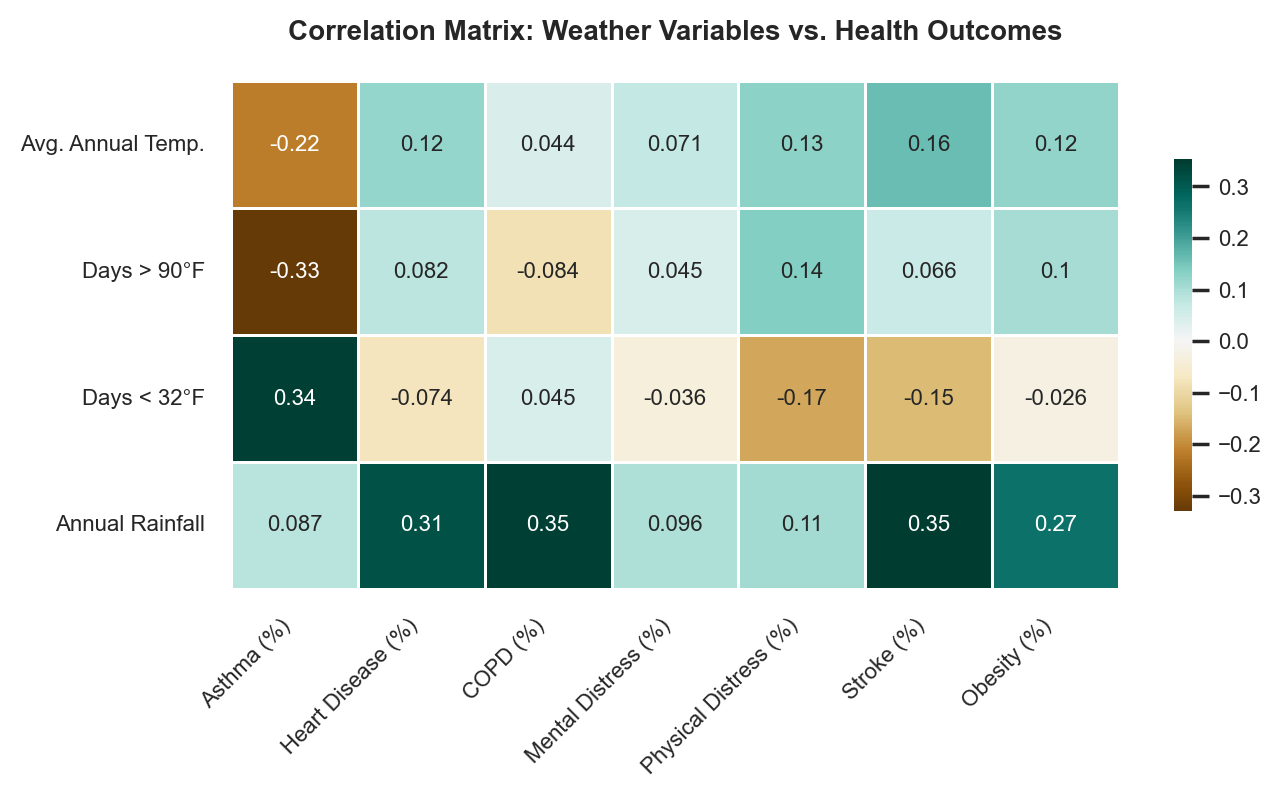

In [85]:
rename_dict = {
    'tavg_n': 'Avg. Annual Temp.',
    'dx90_n': 'Days > 90°F',
    'dt32_n': 'Days < 32°F',
    'prcp_n': 'Annual Rainfall',
    'data_value_cCASTHMA': 'Asthma (%)',
    'data_value_cCHD': 'Heart Disease (%)',
    'data_value_cCOPD': 'COPD (%)',
    'data_value_cMHLTH': 'Mental Distress (%)',
    'data_value_cPHLTH': 'Physical Distress (%)',
    'data_value_cSTROKE': 'Stroke (%)',
    'data_value_cOBESITY': 'Obesity (%)'
}

corr_plot = corr_subset.rename(index=rename_dict, columns=rename_dict)

sns.set(style="white", font_scale=1.1)
plt.figure(figsize=(7, 4))

ax = sns.heatmap(
    corr_plot,
    annot=True,
    cmap="BrBG",
    center=0,
    square=True,          
    linewidths=.5, 
    cbar_kws={"shrink": .6, "pad": 0.05}, 
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix: Weather Variables vs. Health Outcomes",
          fontsize=10, weight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### 4.2. Create scatter plots to visualize relationships

For this visualization, we will choose to portray 3 specific relationships:

* **Frost Days vs. Asthma:** `dt32_n` (annual count of frost days) vs. `data_value_cCASTHMA` (the model-based estimate of the percentage of adults who report currently having asthma).
* **Annual Precipitation vs. Stroke:** `prcp_n` (the cumulative liquid-equivalent measurement of all forms of precipitation recorded over a year) vs. `data_value_cSTROKE` (the model-based estimate of the percentage of adults who report ever having been told by a health professional that they had a stroke).
* **Extreme Heat vs. Asthma:** `dx90_n` (annual count of extreme heat days) vs. `data_value_cCASTHMA`.

We selected these 3 pairs because they represent the strongest statistical correlations between environmental stressors and health outcomes within the dataset.

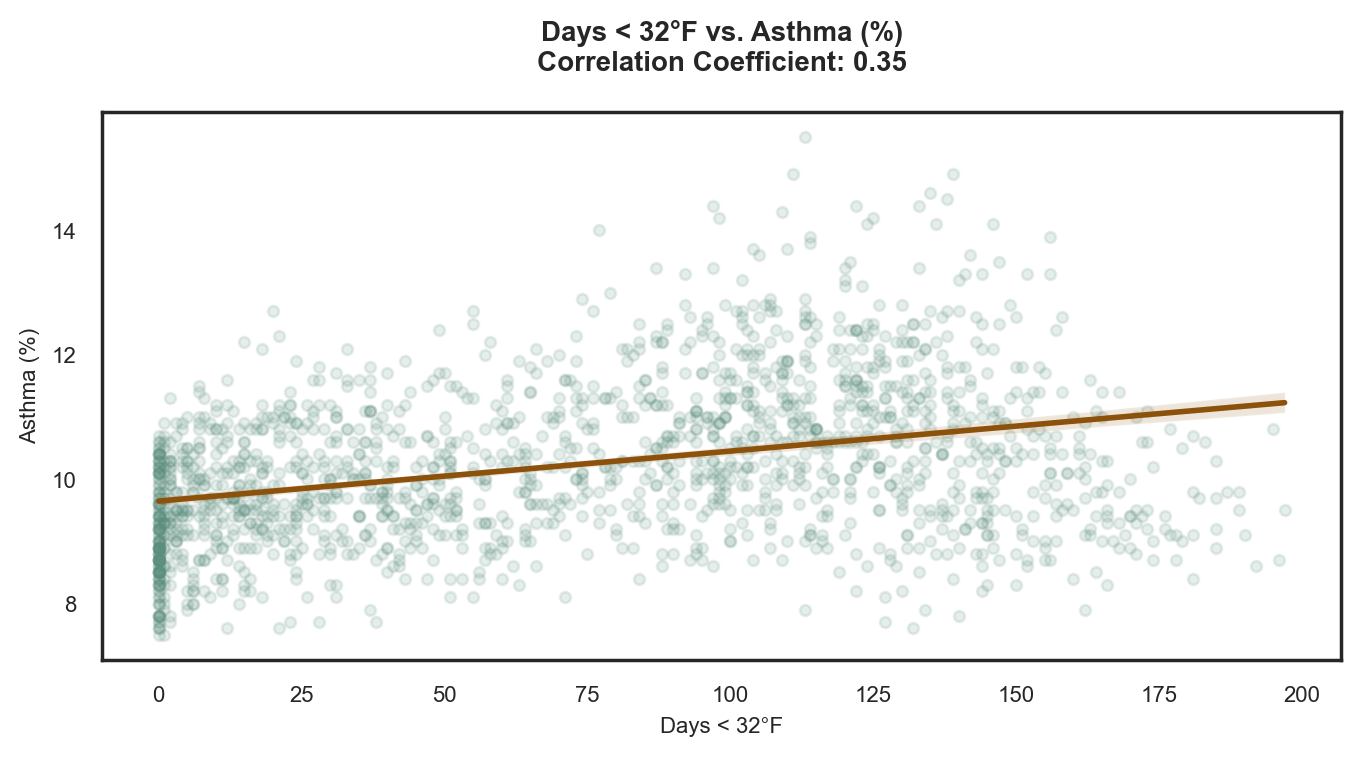

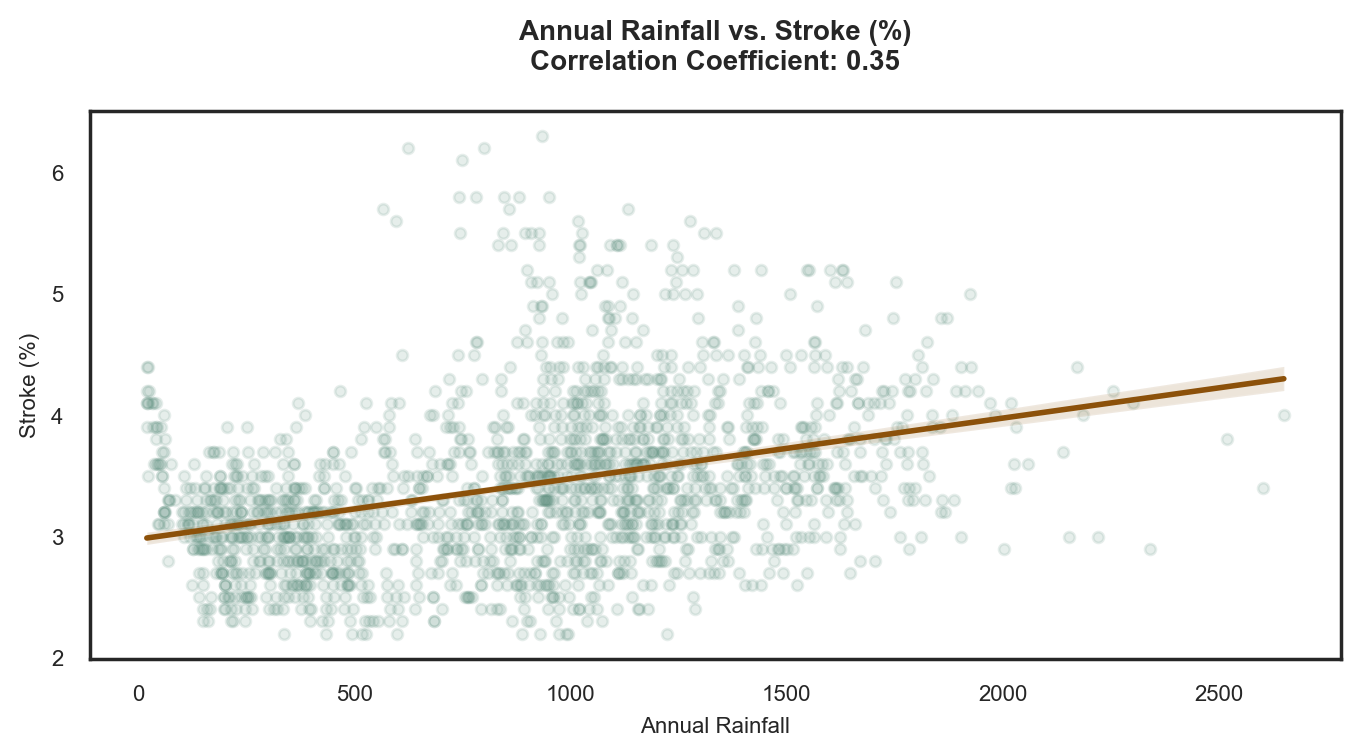

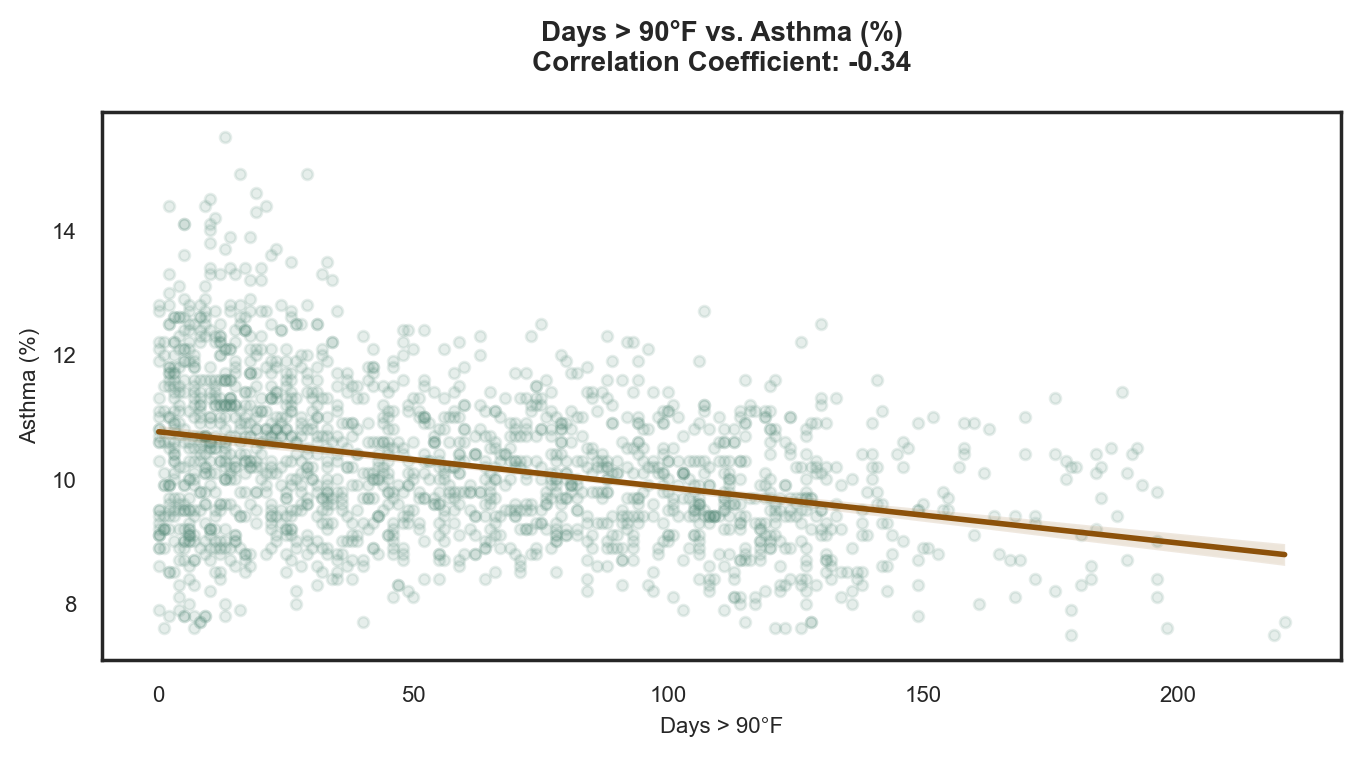

In [76]:
top_pairs = [
    ('dt32_n', 'data_value_cCASTHMA'), 
    ('prcp_n', 'data_value_cSTROKE'),   
    ('dx90_n', 'data_value_cCASTHMA')  
]

sns.set(style="white", font_scale=1.1)

for x, y in top_pairs:

    plt.figure(figsize=(7, 4))
    
    sns.regplot(data=df_pivot, x=x, y=y, 
                scatter_kws={'alpha':0.15, 's':15, 'color':'#5b8e7d'}, 
                line_kws={'color':'#8c510a', 'lw':2})
    
    r_value = df_pivot[x].corr(df_pivot[y])
    
    plt.title(f"{rename_dict[x]} vs. {rename_dict[y]}\nCorrelation Coefficient: {r_value:.2f}", 
              fontsize=10, weight='bold', pad=15)
    
    plt.xlabel(rename_dict[x], fontsize=8)
    plt.ylabel(rename_dict[y], fontsize=8)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

The key takeaways are the following:
* More freezing days correlate with higher asthma rates. Consistently, as the number of extreme heat days increases, asthma rates actually tend to decrease in this specific dataset. 
* There is a moderate positive association between rainfall and stroke: as annual rainfall increases, the population share for stroke tends to rise.

## 5. Visualize bivariate relationships II: Health vs. socio-economic status

### 5.1. Compute a correlation matrix and plot the heatmap

We will recycle the health outcome variables from before, and we will also use some socioeconomic stressors:

* **median_household_income_u:**
* **pct_bachelors_plus_u:**
* **median_age_u:**
* **pct_male_u:**
* **pct_white_u:**
* **pct_black_u:**
* **pct_hispanic_u:**

First, we define the socioeconomic variables.

In [114]:
socioecon_vars = [
    'median_household_income_u', 
    'pct_bachelors_plus_u', 
    'median_age_u',
    'pct_male_u',
    'pct_white_u',
    'pct_black_u',
    'pct_hispanic_u'
]

Then, we create a correlation matrix which runs a Pearson Correlation for each possible pair. We use `.dropna()` here to ensure we only correlate rows that have both weather and health data. In other words, `.dropna()` keeps only rows where _all_ 10 variables are non-missing.

In [101]:
corr_matrix_socioecon = df_pivot[socioecon_vars + health_vars].dropna().corr()
corr_subset_socioecon = corr_matrix_socioecon.loc[socioecon_vars, health_vars]

print('Shape of data set containing NAs:', df_pivot[health_vars + socioecon_vars].shape)
print('Shape of data set excluding NAs:', df_pivot[health_vars + socioecon_vars].dropna().shape)
print(corr_subset_socioecon)

Shape of data set containing NAs: (1818, 14)
Shape of data set excluding NAs: (1524, 14)
                           data_value_cCASTHMA  data_value_cCHD  data_value_cCOPD  data_value_cMHLTH  data_value_cPHLTH  \
median_household_income_u             0.114851        -0.532106         -0.437061           0.177113          -0.322404   
pct_bachelors_plus_u                  0.238505        -0.129989          0.021485           0.170524          -0.113435   
median_age_u                          0.282705         0.019507          0.192730           0.211131           0.031901   
pct_male_u                           -0.203779        -0.306950         -0.339975          -0.106823          -0.216862   
pct_white_u                           0.192340        -0.018107          0.165112           0.022391          -0.209142   
pct_black_u                           0.150615         0.329980          0.348779           0.173733           0.199044   
pct_hispanic_u                       -0.352790    

To visualize the relationships, we can create a heatmap, or, a "Weather-Health" map (retaining only correlations between weather and health variables, and not autocorrelations).

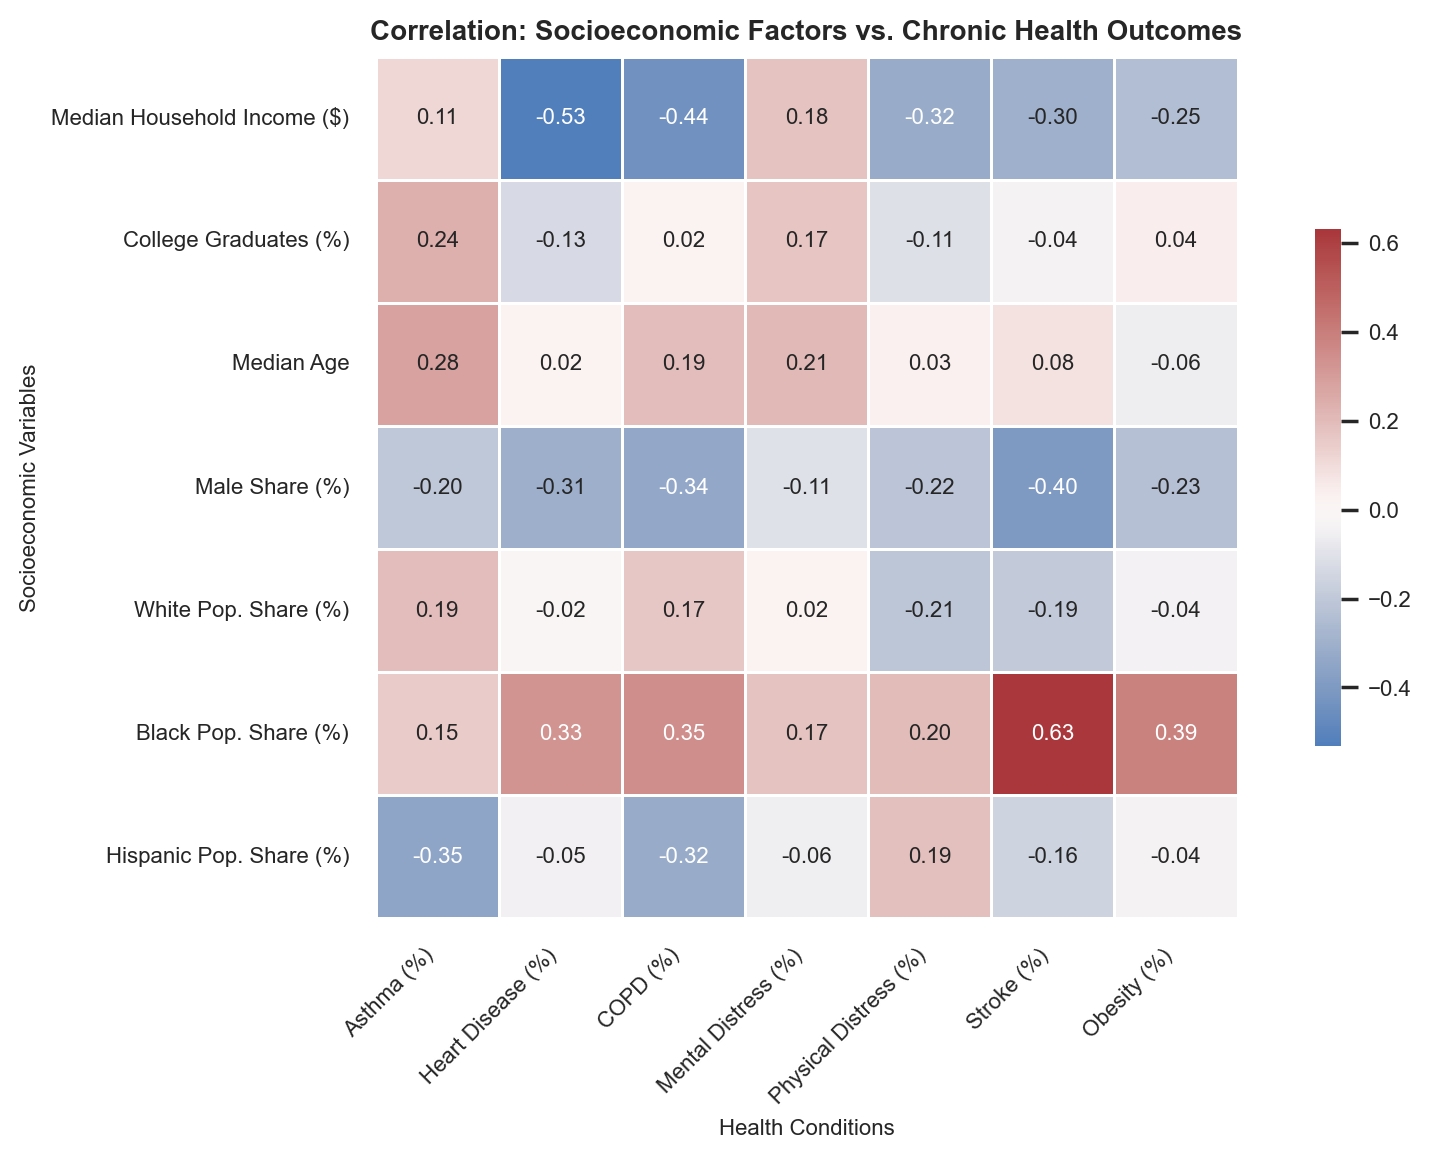

In [113]:
rename_dict.update({
    'median_household_income_u': 'Median Household Income ($)',
    'pct_bachelors_plus_u': 'College Graduates (%)',
    'median_age_u': 'Median Age',
    'pct_male_u': 'Male Share (%)',
    'pct_female_u': 'Female Share (%)',
    'pct_white_u': 'White Pop. Share (%)',
    'pct_black_u': 'Black Pop. Share (%)',
    'pct_hispanic_u': 'Hispanic Pop. Share (%)'
})

corr_matrix_socioecon = df_pivot[socioecon_vars + health_vars].dropna().corr().loc[socioecon_vars, health_vars]

corr_matrix_socioecon.index = [rename_dict.get(x, x) for x in corr_matrix_socioecon.index]
corr_matrix_socioecon.columns = [rename_dict.get(x, x) for x in corr_matrix_socioecon.columns]

plt.figure(figsize=(9, 6))

ax_socioecon = sns.heatmap(corr_matrix_socioecon, 
            annot=True,          
            fmt=".2f", 
            cmap='vlag',     
            center=0,
            square=True, 
            linewidths=.5,
            cbar_kws={"shrink": .6, "pad": 0.05}, 
            annot_kws={"size": 8})

plt.title("Correlation: Socioeconomic Factors vs. Chronic Health Outcomes", fontsize=10, weight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.xlabel("Health Conditions", fontsize=8)
plt.ylabel("Socioeconomic Variables", fontsize=8)

cbar = ax_socioecon.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

We can immediately notice something that seems consistent with general medical facts: there is a moderate-to-high association between the share of black population and the model-based estimate of the percentage of adults who report ever having been told by a medical professional that they had a stroke.

See, for example: https://www.stroke.org/en/help-and-support/resource-library/lets-talk-about-stroke/black-americans.

### 5.2. Create scatter plots to visualize relationships

First, we check the relationship between gender split and the selected health outcomes.

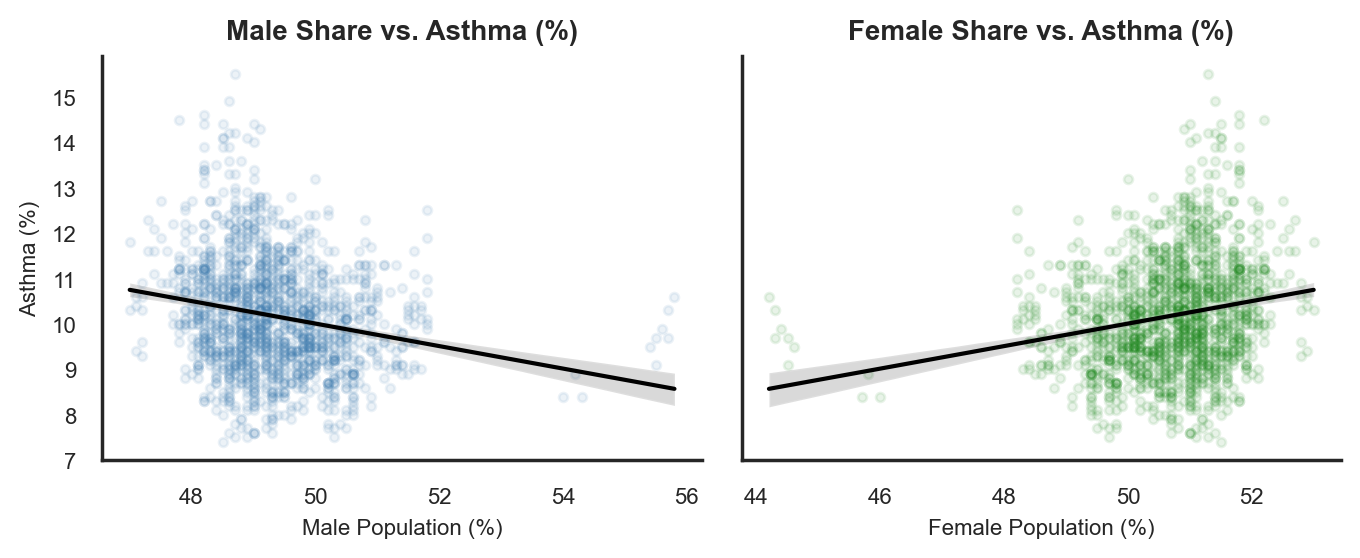

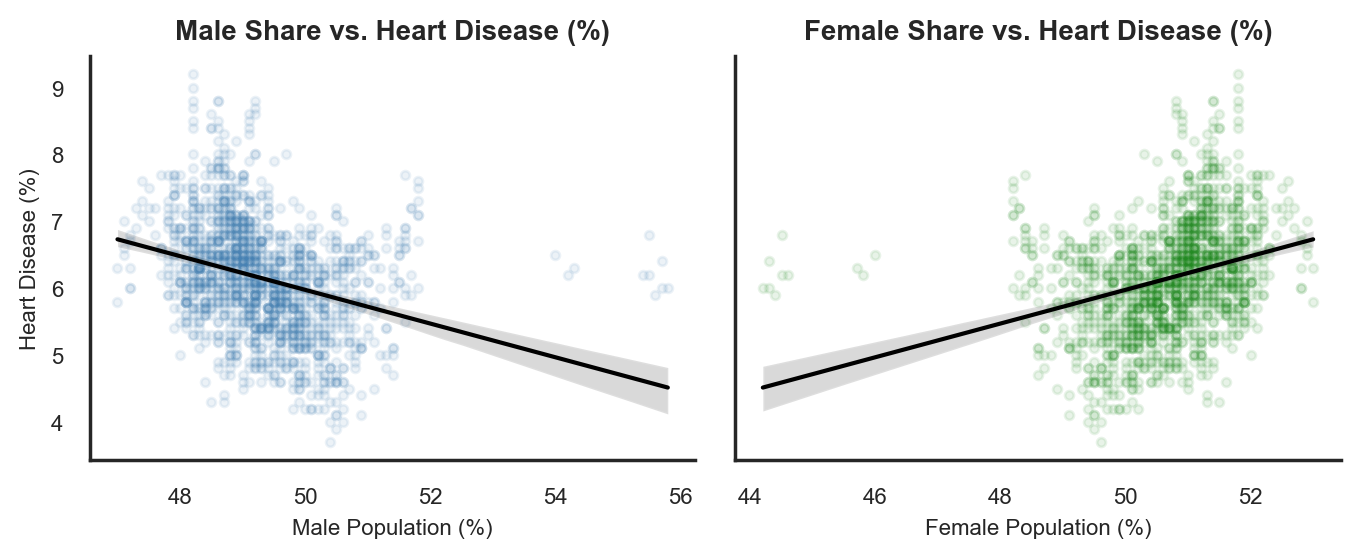

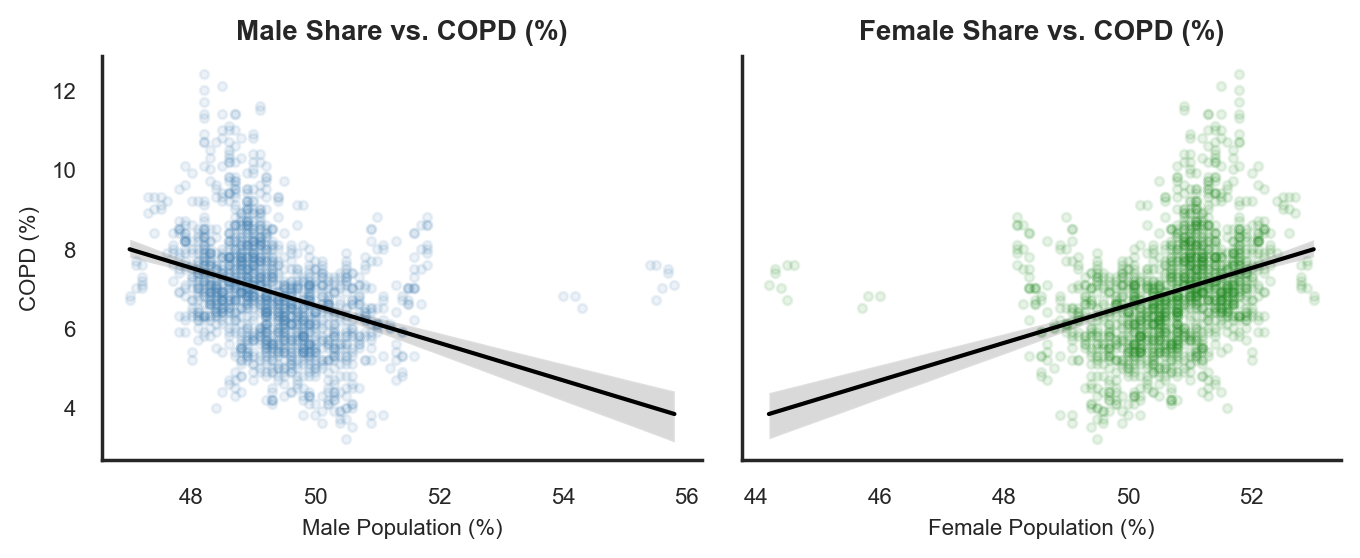

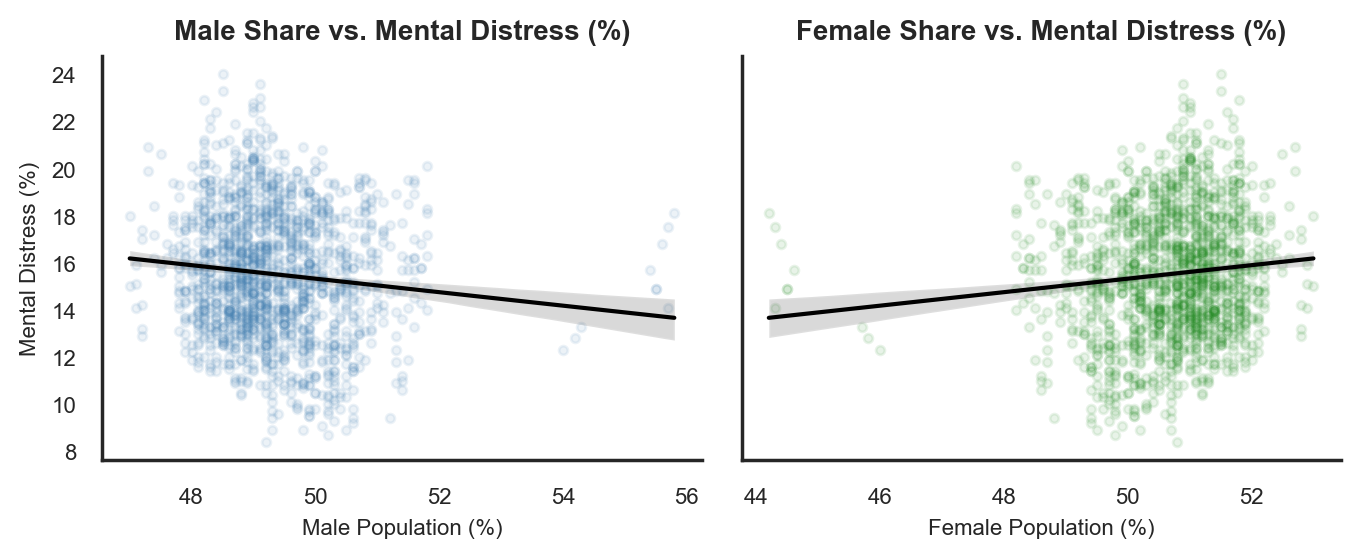

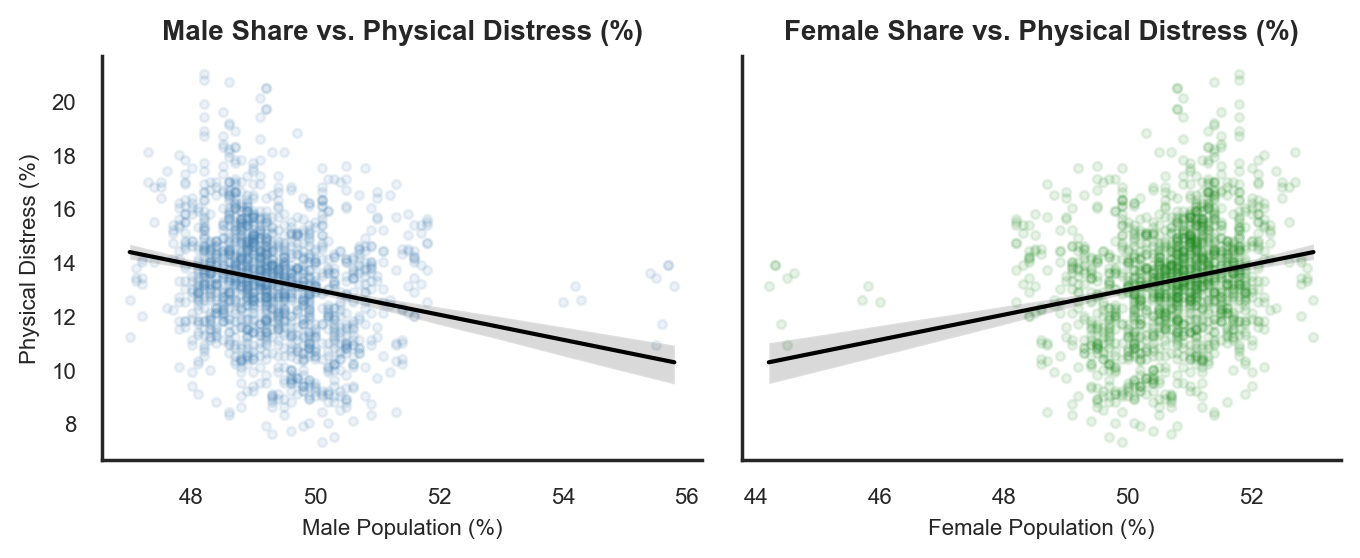

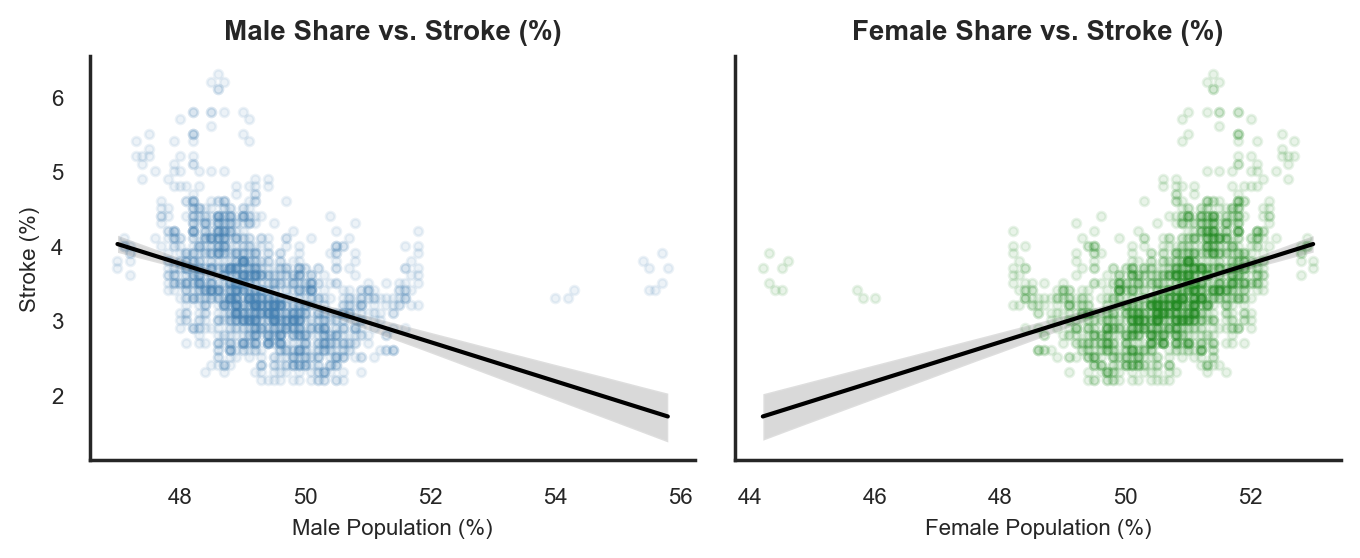

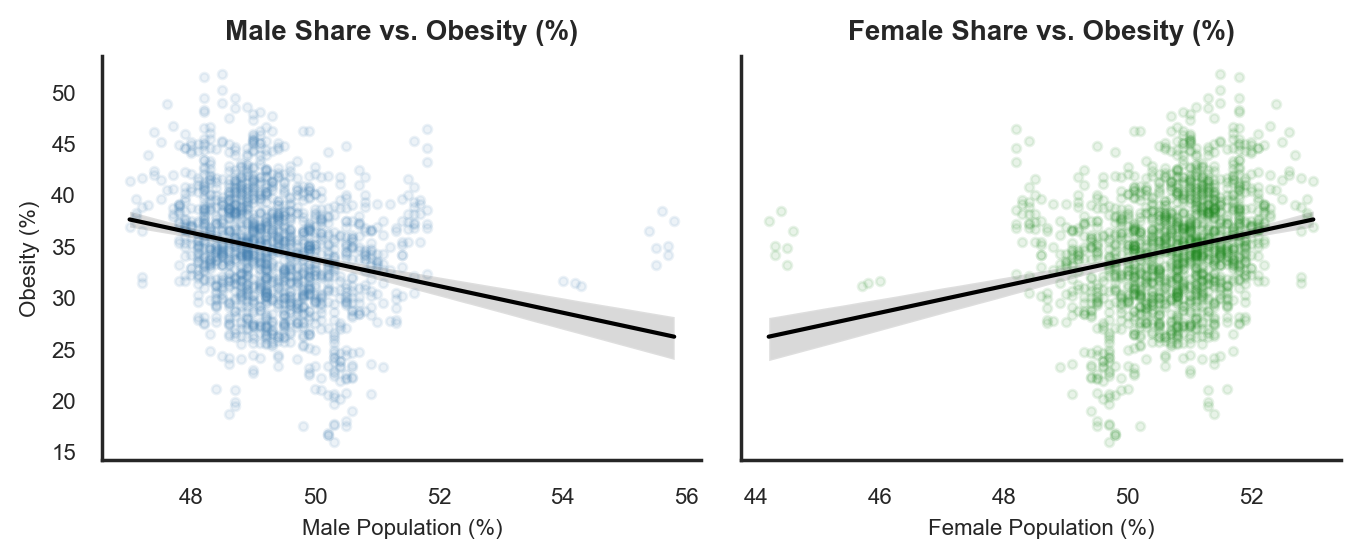

In [ ]:
for var in health_vars:
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

    pretty_name = rename_dict.get(var, var)

    sns.regplot(data=df_pivot, x='pct_male_u', y=var, 
                ax=ax1, color='steelblue', 
                scatter_kws={'alpha': 0.1, 's': 10}, 
                line_kws={'color': 'black', 'lw': 1.5})
    
    ax1.set_title(f"Male Share vs. {pretty_name}", fontsize=10, weight='bold')
    ax1.set_xlabel("Male Population (%)", fontsize=8)
    ax1.set_ylabel(f"{pretty_name}", fontsize=8)

    sns.regplot(data=df_pivot, x='pct_female_u', y=var, 
                ax=ax2, color='forestgreen', 
                scatter_kws={'alpha': 0.1, 's': 10}, 
                line_kws={'color': 'black', 'lw': 1.5})
    
    ax2.set_title(f"Female Share vs. {pretty_name}", fontsize=10, weight='bold')
    ax2.set_xlabel("Female Population (%)", fontsize=8)
    ax2.set_ylabel("", fontsize=8) 

    for ax in [ax1, ax2]:
        ax.tick_params(labelsize=8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

The key takeaway is the following: in all cases, a higher female share seems to be associated with higher disease estimates.